In [124]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

import trajectory as T
from PlanetaryData import Earth, Luna, Sun
from Spice import SpiceImporter
from algorithms import ChristianRobinson
from Constants import RAD_TO_DEG, DEG_TO_RAD

## Physical Plots

In [125]:
def circle_points(radius, N = 100, position = None):
    p = (0,0) if position is None else position
    t = np.linspace(0, np.pi * 2, N, endpoint=False)
    return [radius * np.cos(t) + p[0], radius * np.sin(t) + p[1]]

def noise(cov):
    return np.random.multivariate_normal(
        mean = np.zeros(cov.shape[0]),
        cov=cov
    )

R_example = np.array([
    [0.5, 0, 0],
    [0, 0.5, 0],
    [0, 0, 0]
])
print(f"Example noise: {noise(R_example)}\nwith R = \n{R_example}")

Example noise: [-0.28266795  1.83953926  0.        ]
with R = 
[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0. ]]


In [126]:
spicer = SpiceImporter()
spicer.download_kernels()
spicer.load_kernels()

t = datetime(2026, 6, 13, 11, 25, 00, tzinfo=pytz.utc)

moon_data = spicer.get_state(body_name="MOON", time=t, observer="MOON")
earth_data = spicer.get_state(body_name="EARTH", time=t, observer="MOON")
sun_data = spicer.get_state(body_name="SUN", time=t, observer="MOON")

print(moon_data)
print(earth_data)
print(sun_data)

  naif0012.tls already exists
  gm_de440.tpc already exists
  de440.bsp already exists
Download complete!
Loaded: naif0012.tls
Loaded: gm_de440.tpc
Loaded: de440.bsp
{'name': 'MOON', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(0.0), np.float64(0.0), np.float64(0.0))}
{'name': 'EARTH', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(-186683.7836890456), np.float64(-267712.9161101574), np.float64(-150348.4803498691))}
{'name': 'SUN', 'time': datetime.datetime(2026, 6, 13, 11, 25, tzinfo=<UTC>), 'position': (np.float64(20663888.29961702), np.float64(137804952.6267263), np.float64(59701925.59536826))}


In [127]:
# If we want to do stuff like eclipse
Luna.position = moon_data["position"]
Earth.position = earth_data["position"] # w.r.t Moon
Sun.position = sun_data["position"] # w.r.t Moon

body = Luna
# State
r = 1500 + body.radius
v = np.sqrt(body.mu / r)
orb_period = 2 * np.pi * np.sqrt(r*r*r/body.mu)
print(f"T = {orb_period}s")
state0 = [
    r, 0, 0,
    0, v, 0]

# Time
tf = orb_period / 2
dt = 0.1

# Propagator
op = T.OrbitPropagator(state0, tf, dt, [Sun, Earth, Luna])
op.simulate()

T = 16525.074464841775s


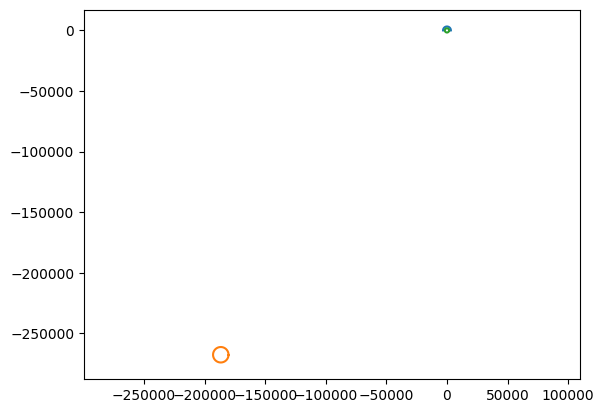

In [128]:
plt.plot(op.states[:,0], op.states[:,1])
plt.plot(*circle_points(Earth.radius, position=Earth.position[0:2]))
plt.plot(*circle_points(Luna.radius, position=Luna.position[0:2]))
# plt.plot(*circle_points(Sun.radius, Sun.position[0:2]))
plt.axis('equal')
plt.show()

## CR

Running CR

In [129]:
# K_inv

# 30x20 cm (3000x2000 px) --> Center at 15,10 (1500x1000 px)
# frame_pixels = np.array([3000, 2000])
# Assumes pixel spacing of 0.10um
mu = .1e-6
focus = 90e-3 # Focal length of 90mm according to https://ntrs.nasa.gov/api/citations/20200000353/downloads/20200000353.pdf
max_angle = 58 * DEG_TO_RAD # JunoCam https://en.wikipedia.org/wiki/JunoCam
print(f"Max angle: {(max_angle * RAD_TO_DEG):f}º")

half_frame_m = np.array([np.tan(max_angle) * focus, np.tan(max_angle) * focus])
half_frame_pixels = half_frame_m / mu
print(f"{half_frame_pixels=}")

dx = dy = focus/mu
alpha = 0
u_p = half_frame_pixels[0]
v_p = half_frame_pixels[1]

K_inv = np.array([
    [1/dx, -alpha/dx/dy, (alpha*v_p - dy*u_p)/dx/dy],
    [0, 1/dy, -v_p/dy],
    [0, 0, 1]
])

print(f"K_inv: {K_inv}")

a = b = c = 3e3 # km
print(f"a = {a} km")
print(f"b = {b} km")
print(f"c = {c} km")

Max angle: 58.000000º
half_frame_pixels=array([1440301.07613695, 1440301.07613695])
K_inv: [[ 1.11111111e-06  0.00000000e+00 -1.60033453e+00]
 [ 0.00000000e+00  1.11111111e-06 -1.60033453e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
a = 3000.0 km
b = 3000.0 km
c = 3000.0 km


In [130]:
# Geometry for center image of 3-4-5
# # angle = np.atan(3/4) * RAD_TO_DEG
# apparent_radius_m = focus * np.tan(max_angle)
# apparent_radius_px = apparent_radius_m / mu
# print(f"Apparent radius on image plane: {apparent_radius_m}m = {apparent_radius_px}px")
# # apparent_radius_px = 675

In [131]:
# apparent_radius_px = 300000
# ratio = apparent_radius_px / half_frame_pixels[0]
# curvature_scale = max_angle / np.tan(max_angle)

# cross_boresight_arc = a / ratio
# boresight_dist = cross_boresight_arc / max_angle
# cross_boresight_dist = boresight_dist * np.tan(max_angle)

# print(f"Arc length on image plane: {apparent_radius_px}px")
# # print(f"Ratio to account for image curvature: {curvature_scale}")
# # print(f"{ratio=}")
# # print(f"{horizontal_dist=}")
# print(f"{cross_boresight_arc=}m")
# print(f"{cross_boresight_dist=}m")

# print(f"{boresight_dist=}")
# # print(f"Distance accounting for curvature scale: {boresight_dist * curvature_scale}")

# # actual_x = boresight_dist * np.sin(max_angle)
# # print(f"{actual_dist=}")



# # [-7.75432373e+03  1.16143593e-02  1.04143585e+04]

In [150]:
apparent_radius_px = 500000
ratio = apparent_radius_px / half_frame_pixels[0]
curvature_scale = 2*np.sin(max_angle/2) / np.tan(max_angle)


cross_boresight = a / ratio
cross_boresight_actual = cross_boresight / curvature_scale
boresight_dist = cross_boresight_actual / np.tan(max_angle)
boresight_dist = cross_boresight / 2 / np.sin(max_angle/2)

actual_dist = norm((cross_boresight_actual, boresight_dist))

print(f"Ratio to account for image curvature: {curvature_scale}")
print(f"{cross_boresight_actual=}m")
print(f"{boresight_dist=}\n")
print(f"Straight line distance accounting for curvature scale: {actual_dist * curvature_scale}")

# actual_x = boresight_dist * np.sin(max_angle)
# print(f"{actual_dist=}")
# 0.6718672738


# [-7.75432373e+03  1.16143593e-02  1.04143585e+04]

Ratio to account for image curvature: 0.6058853464054716
cross_boresight_actual=np.float64(14263.105236148735)m
boresight_dist=np.float64(8912.577325126795)

Straight line distance accounting for curvature scale: 10190.231539919236


In [133]:
# 5000 km away
# body_points = circle_points(apparent_radius_px, position=frame_pixels/2)
# body_points = circle_points(apparent_radius_px, position=(0,0))
body_points = circle_points(apparent_radius_px, position=(0,half_frame_pixels[0]))

N = 100
u_points = np.vstack((np.array(body_points), np.ones((100)))).T

# 10 pixels of covariance
R = np.array([
    [100, 0, 0],
    [0, 100, 0],
    [0, 0, 0]
])

u_noise = np.array([v + noise(R) for v in u_points])


# Makes sure it is in frame
u_in_frame = np.array([v + noise(R) for v in u_points 
                       if v[0] > 0 and v[0] < half_frame_pixels[0]*2
                       and v[1] > 0 and v[1] < half_frame_pixels[1]*2])
u_in_frame = u_noise

(0.0, 2880602.1522738906)

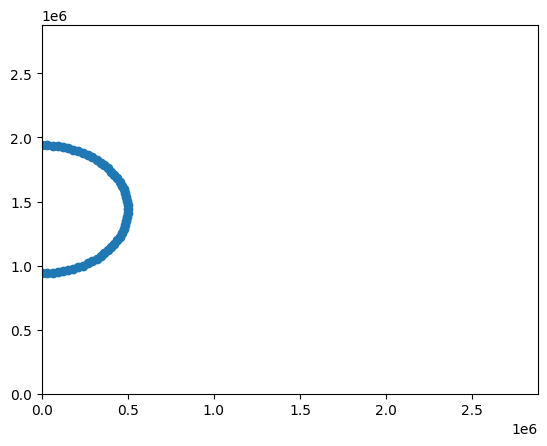

In [134]:
plt.scatter(u_in_frame[:,0], u_in_frame[:,1])
plt.xlim((0, 2*half_frame_pixels[0]))
plt.ylim((0, 2*half_frame_pixels[1]))

In [135]:
# print(u_in_frame)

In [136]:
cr_alg = ChristianRobinson(K_inv, a, b, c)

In [137]:
T_p_c = np.eye(3)
rc = cr_alg.run(u_in_frame, T_p_c)
print(rc)
print(norm(rc))

[-1.03798279e+04  3.07131120e-02  7.25597849e+03]
12664.519382186716
